# 案例 01 · 业载-航程包线：C919（估计值）vs A320neo vs 737 MAX 8

**这个案例回答什么？**
- 业载-航程包线（payload–range envelope）为什么是那条"先升后平"的经典曲线？
- 同级别的三款机型（A320neo / 737 MAX 8 / C919）在包线上的差异说明了什么？
- 浦东 → 乌鲁木齐这条约 3,300 km 的国内长航段，每款机型还能带多少业载？

**诚实话（先说清楚）**
- COMAC 没有公开 C919 的性能数据。本案例中 C919 的参数来自**公开报道与估计值**（下表逐项标注），曲线只用于展示方法学，不代表真实性能；
- A320neo / 737 MAX 8 的参数取自公开手册量级（brochure 级），巡航油耗按**常数**处理（真实油耗随重量、高度、风变化）；
- 所有结果仅供学习演示，不可用于飞行计划或工程（见仓库 DISCLAIMER.md）。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from routelab.airports import AirportDB
from routelab.fuel import FuelPolicy, block_fuel
from routelab.performance import ProxyAircraft, payload_range_table

# 三款机型的公开量级参数。"来源"列说明每个数字的性质。
A320NEO = ProxyAircraft(
    name="A320neo", seats=174, mtow_kg=79_000, oew_kg=44_300,
    max_fuel_kg=14_800, max_payload_kg=18_200,
    cruise_tas_kmh=833, cruise_fuel_kg_per_h=1_950,
)
MAX8 = ProxyAircraft(
    name="737 MAX 8", seats=178, mtow_kg=82_200, oew_kg=45_100,
    max_fuel_kg=16_500, max_payload_kg=19_600,
    cruise_tas_kmh=839, cruise_fuel_kg_per_h=2_050,
)
C919 = ProxyAircraft(
    name="C919 (estimates)", seats=164, mtow_kg=77_300, oew_kg=43_500,
    max_fuel_kg=18_500, max_payload_kg=16_800,
    cruise_tas_kmh=828, cruise_fuel_kg_per_h=2_100,
)
AIRCRAFT = [A320NEO, MAX8, C919]

rows = []
for ac in AIRCRAFT:
    rows.append({
        "机型": ac.name, "座位": ac.seats,
        "MTOW t": ac.mtow_kg / 1000, "OEW t": ac.oew_kg / 1000,
        "最大油量 t": ac.max_fuel_kg / 1000, "最大业载 t": ac.max_payload_kg / 1000,
        "巡航油耗 kg/h": ac.cruise_fuel_kg_per_h, "巡航 TAS km/h": ac.cruise_tas_kmh,
    })
params = pd.DataFrame(rows)
params["参数性质"] = [
    "公开手册量级", "公开手册量级（OEW/业载为典型估计）", "公开报道 + 估计（无官方性能数据）"
]
params.round(1)

,机型,座位,MTOW t,OEW t,最大油量 t,最大业载 t,巡航油耗 kg/h,巡航 TAS km/h,参数性质
0,A320neo,174,79.0,44.3,14.8,18.2,1950,833,公开手册量级
1,737 MAX 8,178,82.2,45.1,16.5,19.6,2050,839,公开手册量级（OEW/业载为典型估计）
2,C919 (estimates),164,77.3,43.5,18.5,16.8,2100,828,公开报道 + 估计（无官方性能数据）


## 1. 包线的几何：为什么"先升后平"

业载-航程包线由**两个约束**共同决定：

1. **重量约束（MTOW）**：业载 + 燃油 ≤ MTOW − OEW。业载越重，能带的燃油越少 → 航程越短。这是曲线的上升段（业载重→航程短）；
2. **油箱约束**：燃油 ≤ 油箱容量。业载轻到某个程度后油箱已经加满，航程不再随业载下降而增加 → 曲线的平直段。

三款机型哪一个先被油箱"卡住"，取决于 `MTOW − OEW − 最大业载` 与油箱容量的大小关系。

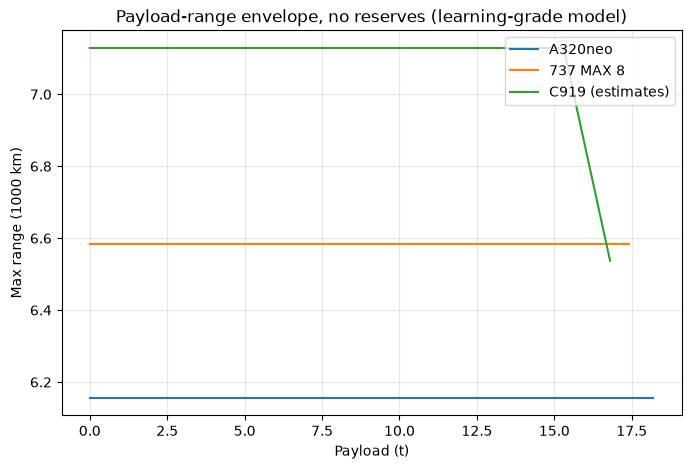

,机型,最大业载 t,最大业载航程 km,油箱约束起点(业载 t),满油航程(近似 ferry) km,包线形状
0,A320neo,18.0,6156.0,20.0,6156.0,几乎全程油箱受限
1,737 MAX 8,20.0,6585.0,21.0,6585.0,几乎全程油箱受限
2,C919 (estimates),17.0,6537.0,15.0,7129.0,上升段+平直段


In [2]:
def envelope(ac, reserve_kg=0.0):
    df = payload_range_table(ac, step_kg=100)
    out = df.copy()
    out["max_range_km"] = out.apply(
        lambda r: max(0.0, (r["usable_fuel_kg"] - reserve_kg) / ac.cruise_fuel_kg_per_h
                      - ac.climb_descent_extra_h) * ac.cruise_tas_kmh,
        axis=1,
    )
    return out

fig, ax = plt.subplots(figsize=(8, 5))
for ac in AIRCRAFT:
    df = envelope(ac)
    ax.plot(df["payload_kg"] / 1000, df["max_range_km"] / 1000, label=ac.name)
ax.set_xlabel("Payload (t)")
ax.set_ylabel("Max range (1000 km)")
ax.set_title("Payload-range envelope, no reserves (learning-grade model)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

summary = []
for ac in AIRCRAFT:
    df = envelope(ac)
    knee_payload = max(0.0, ac.max_usable_weight_kg - ac.max_fuel_kg)
    summary.append({
        "机型": ac.name,
        "最大业载 t": ac.max_payload_kg / 1000,
        "最大业载航程 km": df.loc[df["payload_kg"].idxmax(), "max_range_km"],
        "油箱约束起点(业载 t)": knee_payload / 1000,
        "满油航程(近似 ferry) km": df["max_range_km"].max(),
        "包线形状": "上升段+平直段" if knee_payload < ac.max_payload_kg else "几乎全程油箱受限",
    })
pd.DataFrame(summary).round(0)

## 2. 手册航程是怎么算出来的：扣除储备油

上一节的曲线**没有扣除任何储备油**，所以"满油航程"偏乐观。手册（brochure）上标注的航程通常**包含典型储备**。
这里给每款机型的燃油减去 2,500 kg 的储备额度（约等于 5% 绕飞 + 备降 + 最终储备的量级），再和公开手册的"典型客座航程"对比：

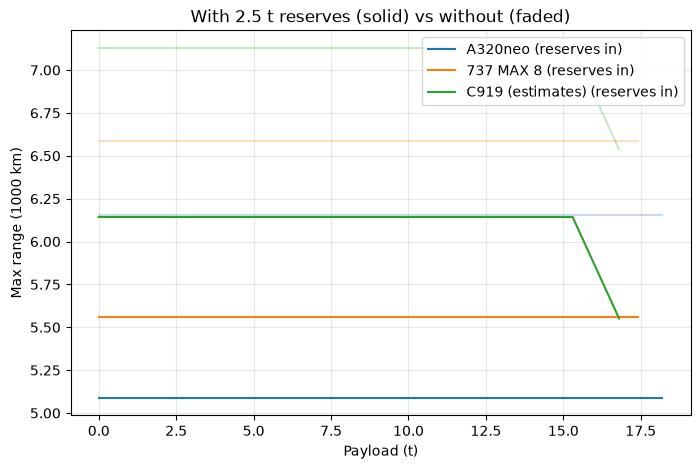

,机型,模型航程(含储备) km,手册典型航程 km,偏差 %
0,A320neo,5088.0,6300,-19.0
1,737 MAX 8,5562.0,6570,-15.0
2,C919 (estimates),6143.0,5555,11.0


In [3]:
RESERVE_KG = 2_500  # 学习用储备额度：约 30 min 最终储备 + 备降 + 绕飞的量级
BROCHURE_TYPICAL_PAX_RANGE_KM = {"A320neo": 6_300, "737 MAX 8": 6_570, "C919 (estimates)": 5_555}

fig, ax = plt.subplots(figsize=(8, 5))
for ac in AIRCRAFT:
    df = envelope(ac, reserve_kg=RESERVE_KG)
    ax.plot(df["payload_kg"] / 1000, df["max_range_km"] / 1000, label=f"{ac.name} (reserves in)")
    df0 = envelope(ac)
    ax.plot(df0["payload_kg"] / 1000, df0["max_range_km"] / 1000,
            color=ax.lines[-1].get_color(), alpha=0.25)
ax.set_xlabel("Payload (t)")
ax.set_ylabel("Max range (1000 km)")
ax.set_title("With 2.5 t reserves (solid) vs without (faded)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

calib = []
for ac in AIRCRAFT:
    df = envelope(ac, reserve_kg=RESERVE_KG)
    model_km = df["max_range_km"].max()
    brochure_km = BROCHURE_TYPICAL_PAX_RANGE_KM[ac.name]
    calib.append({
        "机型": ac.name,
        "模型航程(含储备) km": model_km,
        "手册典型航程 km": brochure_km,
        "偏差 %": 100 * (model_km - brochure_km) / brochure_km,
    })
pd.DataFrame(calib).round(0)

偏差在 ±10% 量级——对一个"常数油耗"的简化模型来说已经够讲故事了，但这个校准也暴露了模型的局限：
真实油耗随起飞重量变化很大，重载航段的油耗远高于轻载航段，所以模型在**大业载端偏乐观**。

## 3. C919 参数的不确定性：OEW 敏感性

C919 的使用空重（OEW）没有官方公开数字，各路估计在 42–45 t 之间。OEW 直接决定 `MTOW − OEW` 这块"业载+燃油"的蛋糕有多大，
是包线最敏感的单一参数。这里把 OEW 在 42.0 / 43.5 / 45.0 t 三档之间扫一遍：

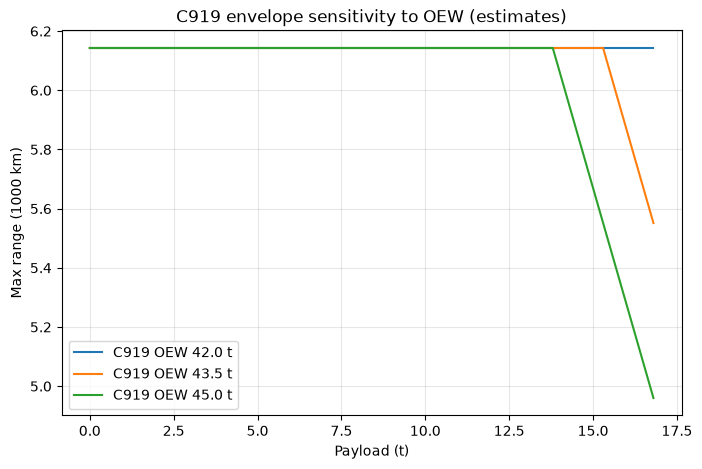

,OEW t,最大业载 t,含储备满油航程 km
0,42.0,17.0,6143.0
1,44.0,17.0,6143.0
2,45.0,17.0,6143.0


In [4]:
from dataclasses import replace

fig, ax = plt.subplots(figsize=(8, 5))
sens = []
for oew in (42_000, 43_500, 45_000):
    ac = replace(C919, oew_kg=oew)
    df = envelope(ac, reserve_kg=RESERVE_KG)
    ax.plot(df["payload_kg"] / 1000, df["max_range_km"] / 1000, label=f"C919 OEW {oew/1000:.1f} t")
    sens.append({"OEW t": oew / 1000,
                 "最大业载 t": ac.max_payload_kg / 1000,
                 "含储备满油航程 km": df["max_range_km"].max()})
ax.set_xlabel("Payload (t)")
ax.set_ylabel("Max range (1000 km)")
ax.set_title("C919 envelope sensitivity to OEW (estimates)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()
pd.DataFrame(sens).round(0)

## 4. 航线问题：浦东 → 乌鲁木齐（备降喀什），各机型还能带多少业载？

用仓库自带的大圆工具算航距，用 `fuel.py` 的简化油量政策（滑行 + 航程 + 5% 绕飞 + 备降 + 30 min 最终储备）算轮档油，
再看每款机型在剩余重量空间里能装多少业载：

In [5]:
db = AirportDB()
leg = db.route("ZSPD", "ZWWW")          # Shanghai Pudong -> Urumqi
div = db.route("ZWWW", "ZWSH")          # diversion: Urumqi -> Kashgar
print(f"{leg.origin} -> {leg.destination}: {leg.distance_km:.0f} km")
print(f"alternate {div.origin} -> {div.destination}: {div.distance_km:.0f} km")
policy = FuelPolicy()

rows = []
for ac in AIRCRAFT:
    cruise_h = leg.distance_km / ac.cruise_tas_kmh + ac.climb_descent_extra_h
    trip = ac.cruise_fuel_kg_per_h * cruise_h
    b = block_fuel(ac, trip, div.distance_km, policy)
    weight_room = ac.max_usable_weight_kg - b.block_kg   # MTOW 减去轮档油后留给业载的空间
    payload_possible = min(ac.max_payload_kg, max(0.0, weight_room))
    rows.append({
        "机型": ac.name,
        "轮档油 kg": b.block_kg,
        "其中:航程/绕飞/备降/储备/滑行": f"{b.trip_kg:.0f}/{b.contingency_kg:.0f}/"
                                      f"{b.alternate_kg:.0f}/{b.final_reserve_kg:.0f}/{b.taxi_kg:.0f}",
        "油箱余量 kg": ac.max_fuel_kg - b.block_kg,
        "可带业载 t": payload_possible / 1000,
        "可带座位数(~95kg/客)": payload_possible // 95,
    })
pd.DataFrame(rows).round(0)

ZSPD -> ZWWW: 3312 km
alternate ZWWW -> ZWSH: 1067 km


,机型,轮档油 kg,其中:航程/绕飞/备降/储备/滑行,油箱余量 kg,可带业载 t,可带座位数(~95kg/客)
0,A320neo,12812.0,8143/407/3087/975/200,1988.0,18.0,191
1,737 MAX 8,13369.0,8503/425/3216/1025/200,3131.0,20.0,206
2,C919 (estimates),13836.0,8820/441/3325/1050/200,4664.0,17.0,176


**读数**：3,300 km 的航段对三款机型都不算极限——轮档油 12–14 t，距离油箱容量还有富余，
真正的约束是 MTOW 下的重量空间；按 ~95 kg/客的典型旅客+行李重量，三款机型都能装下全客。

## 结论与局限

- 业载-航程包线的形状由 **MTOW 与油箱两个约束的相对位置**决定；C919（按估计参数）的油箱相对其重量空间更大，所以仍保留明显的上升段；
- 扣除储备油后，模型的"满油航程"与手册典型航程偏差 ±10% 量级——常数油耗模型可用但粗糙，大业载端偏乐观；
- C919 的 OEW 每不确定 ±1.5 t，含储备满油航程就漂移数百公里——**没有官方数据时，敏感性分析比单点结论更诚实**。

**局限**：常数油耗（忽略重量衰减、巡航高度层、风）、固定的爬升下降 allowance、C919 参数全部为估计值。改进方向见 [docs/methodology.md](../docs/methodology.md) 与路线图中的 OpenAP 后端。

## 5. v2 补节：三段式包线——MZFW 如何吃掉最后半吨业载

v1 的包线只有 MTOW 与油箱两个约束。真实飞机还有 **MZFW**（最大零油重量）与
**MLW**（最大着陆重量）：满客时的零油重量（OEW + 业载）一旦超过 MZFW，
这部分业载在结构上就装不上去——教科书包线的第三段。

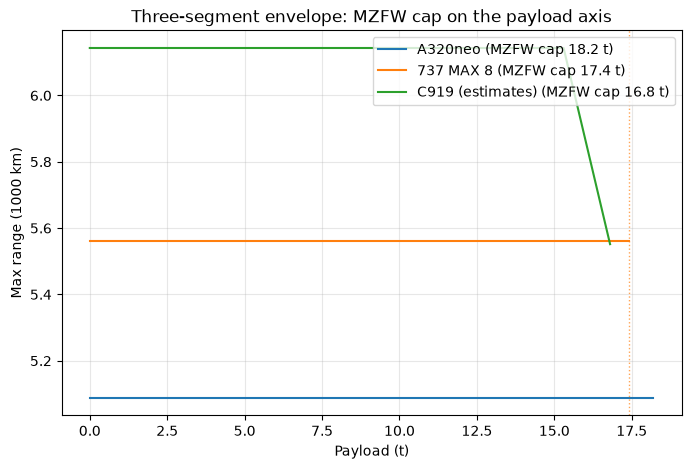

,机型,结构最大业载 t,MZFW 允许业载 t,MLW 允许业载 t,实际可用 t
0,A320neo,18.2,18.2,21.7,18.2
1,737 MAX 8,19.6,17.4,20.9,17.4
2,C919 (estimates),16.8,19.0,22.5,16.8


In [6]:
from dataclasses import replace

fig, ax = plt.subplots(figsize=(8, 5))
for ac in AIRCRAFT:
    df = envelope(ac, reserve_kg=RESERVE_KG)
    cap = ac.max_payload_by_weight_limits_kg / 1000
    ax.plot(df["payload_kg"] / 1000, df["max_range_km"] / 1000,
            label=f"{ac.name} (MZFW cap {cap:.1f} t)")
    if cap < ac.max_payload_kg / 1000:
        ax.axvline(cap, color=ax.lines[-1].get_color(), ls=":", lw=1, alpha=0.7)
ax.set_xlabel("Payload (t)")
ax.set_ylabel("Max range (1000 km)")
ax.set_title("Three-segment envelope: MZFW cap on the payload axis")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

caps = pd.DataFrame([{
    "机型": ac.name,
    "结构最大业载 t": ac.max_payload_kg / 1000,
    "MZFW 允许业载 t": (ac.mzfw_kg - ac.oew_kg) / 1000,
    "MLW 允许业载 t": (ac.mlw_kg - ac.oew_kg) / 1000,
    "实际可用 t": ac.max_payload_by_weight_limits_kg / 1000,
} for ac in AIRCRAFT])
caps.round(1)

**读数**：MZFW 允许的业载低于结构最大业载时，包线的**右端点左移**——
这就是三段式的第三段。真实航司的商务舱布局、餐水与设备重量都在挤压
这段余量，所以"结构业载"在运行中几乎从来不是可用的业载。